# Recs 002: Dense embeddings — per review, mean per game

## Key Goal

Generate raw-text game embeddings and retrieval artifacts (matrix/index/meta) for downstream query retrieval.

## Decision It Supports

Whether raw game embeddings are production-ready as the baseline retrieval index.

## Primary Metrics

Embedding/index integrity checks (shape, normalization, join coverage, retrieval sanity outputs).


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd


def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        if (d / "pyproject.toml").is_file():
            return d
    raise RuntimeError(f"Could not find repo root (no pyproject.toml). cwd={here}")


REPO_ROOT = _repo_root()
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "recs"
REVIEWS_LONG = ARTIFACT_DIR / "game_profile_reviews.parquet"
OUT_NPZ = ARTIFACT_DIR / "game_profile_embeddings.npz"
OUT_INDEX = ARTIFACT_DIR / "game_profile_embedding_index.parquet"
OUT_META = ARTIFACT_DIR / "game_profile_embedding_meta.json"

# English USE; 512-d embeddings. Swap URL on TF Hub if you want multilingual or another Google encoder.
TFHUB_URL = "https://tfhub.dev/google/universal-sentence-encoder/4"
BATCH_SIZE = 64
# Optional: trim very long single reviews before encode (characters). None = no trim (model truncates internally).
MAX_CHARS_PER_REVIEW: int | None = 8000

print("Reviews:", REVIEWS_LONG)
print("TF Hub:", TFHUB_URL)

Reviews: /home/ryanr/workspace/steam_recommendations/artifacts/recs/game_profile_reviews.parquet
TF Hub: https://tfhub.dev/google/universal-sentence-encoder/4


In [2]:
import os

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import tensorflow as tf
import tensorflow_hub as hub
from tqdm.auto import tqdm

gpus = tf.config.list_physical_devices("GPU")
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
    except Exception:
        pass

embed_fn = hub.load(TFHUB_URL)

I0000 00:00:1775422255.395742   16409 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775422256.550609   16409 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python3.11/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/home/ryanr/miniconda3/envs/tf_condaforge/lib/python

## 1) Load per-review table

In [3]:
if not REVIEWS_LONG.is_file():
    raise FileNotFoundError(f"Run recs_001 first. Missing {REVIEWS_LONG}")

df = pd.read_parquet(REVIEWS_LONG)
df = df.dropna(subset=["review"]).copy()
df["review"] = df["review"].astype(str)
df = df[df["review"].str.len() > 0]

if MAX_CHARS_PER_REVIEW is not None:
    df["_text"] = df["review"].str[:MAX_CHARS_PER_REVIEW]
else:
    df["_text"] = df["review"]

df = df.reset_index(drop=True)
print(df.shape, "rows")
print("games:", df["app_id"].nunique())

(62304, 6) rows
games: 315


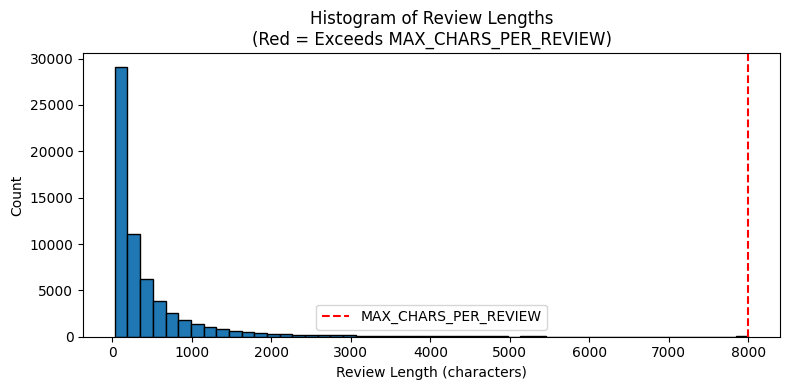

In [4]:
import matplotlib.pyplot as plt

# Compute review lengths (before truncation)
review_lens = df["review"].str.len()

# Plot histogram
fig, ax = plt.subplots(figsize=(8, 4))
n, bins, patches = ax.hist(review_lens, bins=50, edgecolor='k')

# Color bars red if above MAX_CHARS_PER_REVIEW
if MAX_CHARS_PER_REVIEW is not None:
    for patch, bin_left in zip(patches, bins[:-1]):
        # If the right end of the bin exceeds MAX_CHARS_PER_REVIEW, color red
        if bin_left >= MAX_CHARS_PER_REVIEW:
            patch.set_facecolor('red')
        else:
            patch.set_facecolor('C0')

ax.set_xlabel("Review Length (characters)")
ax.set_ylabel("Count")
ax.set_title("Histogram of Review Lengths\n(Red = Exceeds MAX_CHARS_PER_REVIEW)")
if MAX_CHARS_PER_REVIEW is not None:
    ax.axvline(MAX_CHARS_PER_REVIEW, color='red', linestyle='--', label='MAX_CHARS_PER_REVIEW')
    ax.legend()
plt.tight_layout()
plt.show()

## 2) Encode each review, mean-pool per game, L2-normalize

In [5]:
# Convert the processed review texts to a list, to feed into the embedding function
texts = df["_text"].tolist()

# CHUNKS will hold batches of embedded review vectors
chunks: list[np.ndarray] = []

# Batch-encode all reviews for efficiency
for start in tqdm(range(0, len(texts), BATCH_SIZE), desc="encode batches"):
    batch = texts[start : start + BATCH_SIZE]              # Grab a batch from the list
    out = embed_fn(batch)                                  # Embed the batch using the preloaded embedding function
    chunks.append(np.asarray(out, dtype=np.float32))       # Convert the output to np.float32 and collect

# Concatenate all batches back into a single 2D array: (n_reviews, embedding_dim)
emb = np.concatenate(chunks, axis=0)
assert emb.ndim == 2, "emb should be 2D: (n_reviews, embedding_dim)"

# Now aggregate/mean-pool the embeddings by game (app_id).

# These lists will store the per-game outputs and associated metadata
mean_vecs: list[np.ndarray] = []
meta_app: list[int] = []
meta_name: list[str] = []

# Loop over each unique app_id (game), grouped in sorted order
for app_id, g in df.groupby("app_id", sort=True):
    idx = g.index.to_numpy()                    # Get the indices of reviews for this game
    v = emb[idx].mean(axis=0)                   # Mean-pool the review embeddings for this game
    nrm = np.linalg.norm(v)                     # Compute L2 norm

    if nrm > 1e-12:
        v = v / nrm                            # L2 normalize the mean vector (avoid division by zero)
    mean_vecs.append(v.astype(np.float32))      # Store as float32
    meta_app.append(int(app_id))                # Save game id (app_id)
    meta_name.append(str(g["app_name"].iloc[0]))# Save game name

# Build final stacked arrays for all games:
X = np.stack(mean_vecs, axis=0)                 # shape: (n_games, embedding_dim)
app_ids_arr = np.array(meta_app, dtype=np.int64) # shape: (n_games,)

print("embeddings:", X.shape)                   # Show array shape for debugging
X[0, :5]                                       # Display the first vector slice as a sample

encode batches: 100%|██████████| 974/974 [00:20<00:00, 46.85it/s]


embeddings: (315, 512)


array([ 0.00263368, -0.03560973, -0.03392399,  0.01581145,  0.00760896],
      dtype=float32)

In [6]:
import random

# Examine a random embedding: pick a random game (row) and print its app_id, app_name, and embedding (first 10 dims)
idx = random.randint(0, X.shape[0] - 1)
print(f"Random game index: {idx}")
print(f"app_id: {app_ids_arr[idx]}")
print(f"app_name: {meta_name[idx]}")
print(f"embedding[:10]: {X[idx][:10]}")

Random game index: 34
app_id: 221380
app_name: Age of Empires II (2013)
embedding[:10]: [ 0.01686686 -0.0735658  -0.02355035  0.01265816 -0.02309459  0.04364481
  0.02958181 -0.03146765  0.05189431 -0.01276988]


## 2b) What the final embeddings are (plain English)

**`X`** is the **game profile index** you will match queries against in **`recs_003`**.

| In code | In words |
|--------|----------|
| **One row = one game** | Each of the `n_games` rows is a single Steam title (identified by `app_id` / `app_name` in the same row order). |
| **512 numbers per row** | That is the output size of **Universal Sentence Encoder** — a fixed-length **semantic vector**, not readable text. |
| **Where it came from** | For that game, we embedded **each included thumbs-up review**, took the **element-wise average** of those review vectors, then **rescaled** the average to **length 1** (L2 normalize). |
| **How to interpret the digits** | Individual dimensions are **not** like “genre = column 37.” The model mixes meaning across all dimensions. What matters is **geometry**: two games with **similar** review language end up with vectors pointing in **similar directions**. |
| **Why normalize** | Unit length makes **dot product = cosine similarity** between games (and between a query and every game), which is what retrieval uses. |

The next cell prints a few **sanity numbers** (shape, norm check, one example similarity).

In [7]:
n_games, dim = X.shape
norms = np.linalg.norm(X, axis=1)

print("— Shape —")
print(f"  {n_games} games × {dim} dimensions (USE output size).")
print("— L2 norms (should be ~1.0 after normalize) —")
print(f"  min={norms.min():.6f}  max={norms.max():.6f}  mean={norms.mean():.6f}")
print("— Example —")
print(f"  Row 0: {meta_name[0]} (app_id={app_ids_arr[0]})")
print(f"  Row 1: {meta_name[1]} (app_id={app_ids_arr[1]})")
cos_01 = float(X[0] @ X[1])
print(f"  Cosine similarity (dot product) between row 0 and row 1: {cos_01:.4f}")
print("    (1 = same direction, 0 = orthogonal, negative = opposite-ish in this space.)")

— Shape —
  315 games × 512 dimensions (USE output size).
— L2 norms (should be ~1.0 after normalize) —
  min=1.000000  max=1.000000  mean=1.000000
— Example —
  Row 0: Half-Life (app_id=70)
  Row 1: Counter-Strike: Source (app_id=240)
  Cosine similarity (dot product) between row 0 and row 1: 0.8721
    (1 = same direction, 0 = orthogonal, negative = opposite-ish in this space.)


## 3) Review embeddings for a list of games

After **`X`** is built, inspect **L2-normalized** vectors for games you care about. Edit **`REVIEW_APP_IDS`** (and optionally **`REVIEW_NAME_CONTAINS`**) below (or use **`SHOW_ALL_GAMES`**).

- **`l2_norm`** should be **~1.0** (numerical float error is normal).
- **Pairwise table** is **cosine similarity** (same as dot product here).

,app_id,app_name,l2_norm,dim,first_8_dims
0,70,Half-Life,1.0,512,[ 0.0026 -0.0356 -0.0339 0.0158 0.0076 -0.03...
1,420,Half-Life 2: Episode Two,1.0,512,[ 0.0177 -0.0596 -0.0216 0.0155 0.0298 -0.06...
2,620,Portal 2,1.0,512,[ 0.0103 -0.0522 -0.0274 0.013 0.0213 -0.00...
3,8930,Sid Meier's Civilization V,1.0,512,[ 0.0184 -0.0971 -0.0319 0.0066 0.012 0.03...
4,72850,The Elder Scrolls V: Skyrim,1.0,512,[-0.0003 -0.0563 0.0023 0.0081 0.0193 0.04...
5,105600,Terraria,1.0,512,[ 0.0077 -0.0647 -0.0204 -0.0001 0.0037 0.01...
6,289070,Sid Meier's Civilization VI,1.0,512,[ 0.0005 -0.0993 -0.0122 -0.0133 0.0155 0.04...
7,292030,The Witcher 3: Wild Hunt,1.0,512,[-0.0158 -0.0579 -0.0113 0.0385 0.0018 0.00...
8,306130,The Elder Scrolls Online,1.0,512,[-0.0197 -0.0765 0.0294 0.0219 0.0392 0.05...
9,413150,Stardew Valley,1.0,512,[ 0.0137 -0.0622 -0.0153 0.0292 -0.0254 0.02...


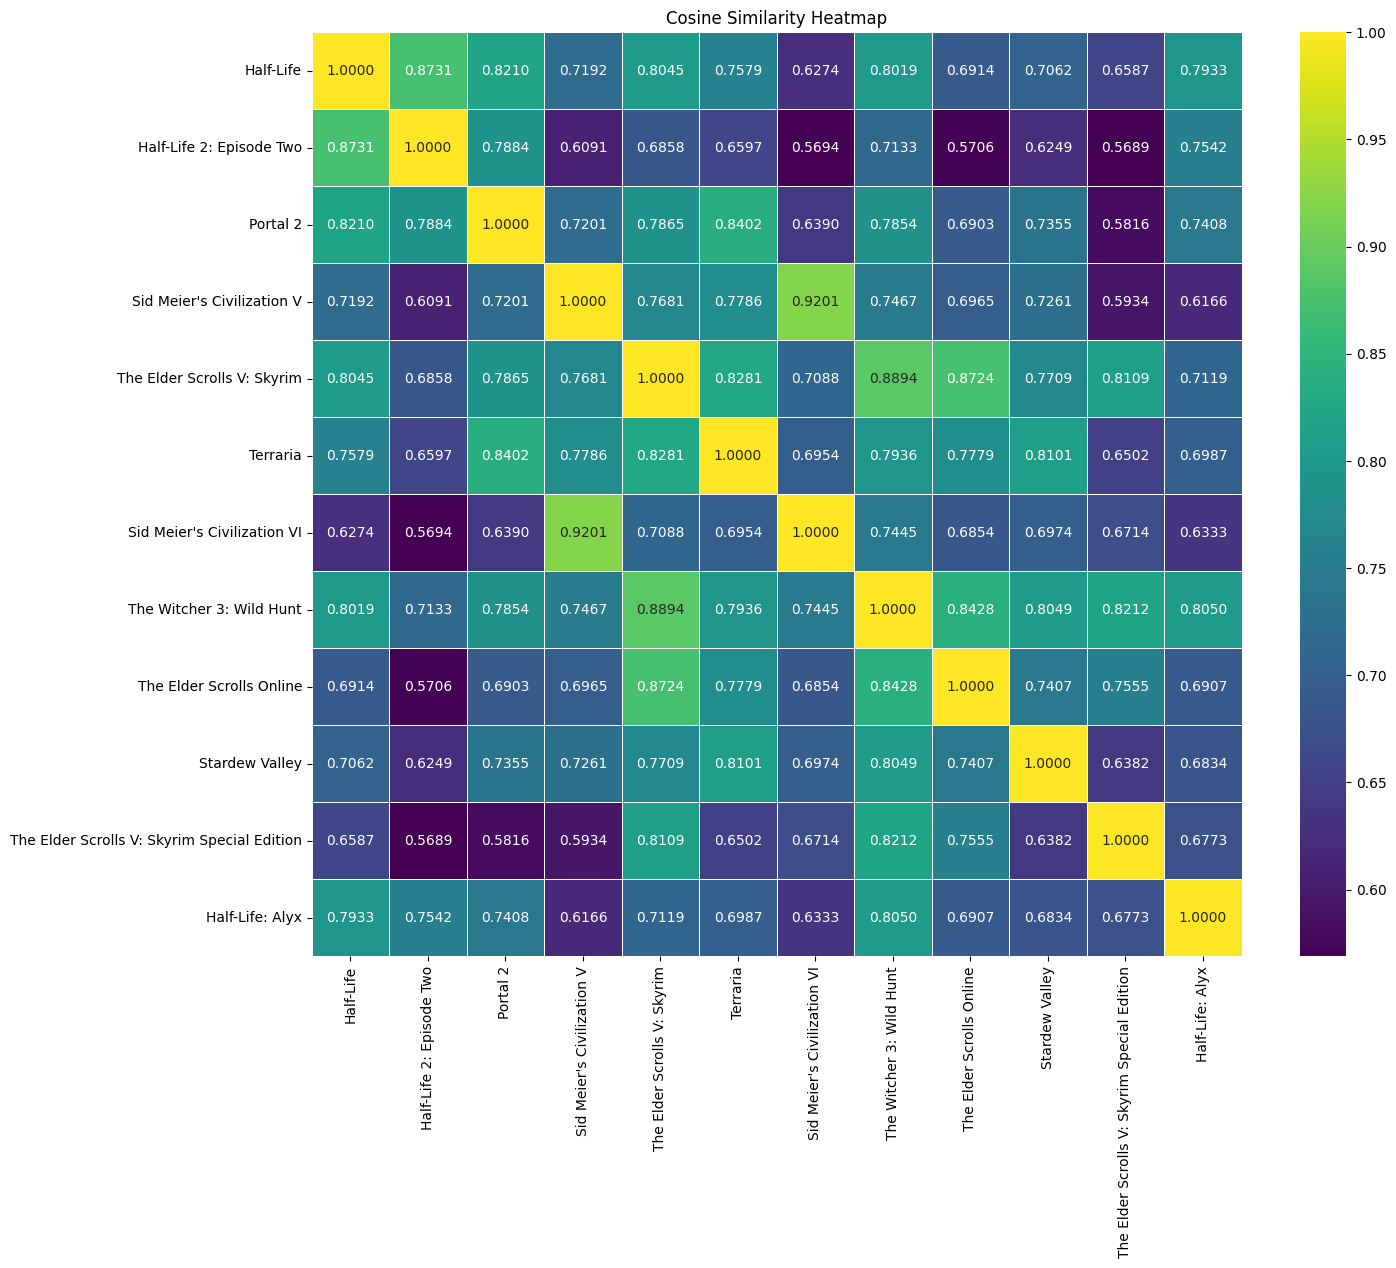

In [12]:
# Pick games by app_id (primary) and/or name substring (extra rows).
# To show all game names, set SHOW_ALL_GAMES = True.
SHOW_ALL_GAMES = False  # Set to True to just see the whole list
REVIEW_APP_IDS: list[int] = [
    # 70,  # Half-Life — replace / extend with app_ids from your index
]
REVIEW_NAME_CONTAINS: list[str] = [
    "Portal",
    "Half-Life",
    "Civilization",
    "Stardew Valley",
    "Terraria",
    "Minecraft",
    "The Witcher",
    "The Elder Scrolls",
]

_index_tbl = pd.DataFrame({"app_id": meta_app, "app_name": meta_name})
_row_by_app = {int(a): i for i, a in enumerate(meta_app)}

if SHOW_ALL_GAMES:
    display(_index_tbl)
else:
    picked_rows: list[int] = []
    for a in REVIEW_APP_IDS:
        if a in _row_by_app:
            picked_rows.append(_row_by_app[a])
        else:
            print(f"[missing app_id] {a}")
    for sub in REVIEW_NAME_CONTAINS:
        if not sub:
            continue
        m = _index_tbl[_index_tbl["app_name"].str.contains(sub, case=False, regex=False, na=False)]
        for _, r in m.iterrows():
            picked_rows.append(_row_by_app[int(r["app_id"])])

    picked_rows = sorted(set(picked_rows))
    if not picked_rows:
        print("No games matched. Set REVIEW_APP_IDS or REVIEW_NAME_CONTAINS, or set SHOW_ALL_GAMES = True to see everything.")
    else:
        sel = np.array(picked_rows, dtype=np.int64)
        V = X[sel]
        names = [_index_tbl["app_name"].iloc[i] for i in picked_rows]
        app_ids = [_index_tbl["app_id"].iloc[i] for i in picked_rows]

        review_df = pd.DataFrame(
            {
                "app_id": app_ids,
                "app_name": names,
                "l2_norm": np.linalg.norm(V, axis=1),
                "dim": V.shape[1],
                "first_8_dims": [np.array2string(V[j, :8], precision=4, suppress_small=True) for j in range(len(sel))],
            }
        )
        display(review_df)

        if len(sel) >= 2:
            import matplotlib.pyplot as plt
            import seaborn as sns

            sim = V @ V.T
            sim_df = pd.DataFrame(sim, index=names, columns=names).round(4)
            plt.figure(figsize=(len(names) * 1.25, len(names)))
            sns.heatmap(sim_df, annot=True, fmt=".4f", cmap="viridis", linewidths=0.5)
            plt.title("Cosine Similarity Heatmap")
            plt.yticks(rotation=0)
            plt.show()

## 4) Save artifacts

In [9]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
np.savez_compressed(OUT_NPZ, embeddings=X, app_id=app_ids_arr)
pd.DataFrame({"app_id": meta_app, "app_name": meta_name}).to_parquet(OUT_INDEX, index=False)
meta = {
    "model_name": TFHUB_URL,
    "backend": "tensorflow",
    "method": "encode_each_review_mean_pool_per_app_id_l2_normalize",
    "max_chars_per_review": MAX_CHARS_PER_REVIEW,
    "n_games": int(X.shape[0]),
    "dim": int(X.shape[1]),
    "n_review_rows_encoded": int(len(df)),
}
OUT_META.write_text(json.dumps(meta, indent=2), encoding="utf-8")
print("Wrote", OUT_NPZ)
print("Wrote", OUT_INDEX)
print("Wrote", OUT_META)

Wrote /home/ryanr/workspace/steam_recommendations/artifacts/recs/game_profile_embeddings.npz
Wrote /home/ryanr/workspace/steam_recommendations/artifacts/recs/game_profile_embedding_index.parquet
Wrote /home/ryanr/workspace/steam_recommendations/artifacts/recs/game_profile_embedding_meta.json
